In [65]:
#1D - SOM for Snow-Depth Change Clustering
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#sklearn
from sklearn.metrics import accuracy_score, classification_report, root_mean_squared_error, r2_score, confusion_matrix
from sklearn.decomposition import PCA
import seaborn as sns


In [23]:
#upload the data
df = pd.read_csv('data/input_df_SUMMmet.csv')  

#clean out rows with nan entries and columns that are completely nan
df = df.dropna(axis=1, how='all')
df = df.dropna()

#dropping irrelavant sites
sites_to_drop = ['PTSH', 'SPST', 'SR01', 'SR25', 'SR11']
df = df[~df['site.x'].isin(sites_to_drop)]

In [51]:
#build snow change target
threshold = 1e-6
y = pd.Series(3, index=df.index)   # default no-change
y[df['delta'] > threshold] = 1     # accumulation
y[df['delta'] < -threshold] = 2    # ablation
y = y.astype(int)

#build features as well
X = df.drop(columns=[
    'Unnamed: 0', 'date', 'site.x', 'site.y',
    'SNOD', 'delta', 'X'
])
# Convert to matrix
X = X.astype(float)

#scale and standardize features as well
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#normalize
# X = (X - X.min()) / (X.max() - X.min())
# X_scaled = X.values

In [52]:
#full SOM class defined for 1d usage

class OneDSOM:
    def __init__(self, n_nodes=3, n_features=10, 
                 learning_rate=0.5, sigma=1.0, n_epochs=200):
        self.n_nodes = n_nodes
        self.n_features = n_features
        self.learning_rate = learning_rate
        self.initial_lr = learning_rate
        self.sigma = sigma
        self.initial_sigma = sigma
        self.n_epochs = n_epochs
        
        # initialize weights randomly
        self.weights = np.random.rand(n_nodes, n_features)

    # ---------------------
    # Best Matching Unit
    # ---------------------
    def find_bmu(self, x):
        distances = np.linalg.norm(self.weights - x, axis=1)
        return np.argmin(distances)

    # ---------------------
    # Gaussian Neighborhood
    # ---------------------
    def neighborhood(self, i, bmu_idx, sigma):
        return np.exp(-(np.abs(i - bmu_idx)**2) / (2 * sigma**2))

    # ---------------------
    # Train SOM
    # ---------------------
    def fit(self, X):

        for epoch in range(self.n_epochs):
            lr = self.initial_lr * np.exp(-epoch / self.n_epochs)
            sigma = self.initial_sigma * np.exp(-epoch / self.n_epochs)

            # shuffle data for each epoch
            idxs = np.random.permutation(len(X))

            for idx in idxs:
                x = X[idx]

                bmu_idx = self.find_bmu(x)

                # update each node in the 1D SOM
                for i in range(self.n_nodes):
                    h = self.neighborhood(i, bmu_idx, sigma)
                    self.weights[i] += lr * h * (x - self.weights[i])

    # ---------------------
    # Assign samples to SOM nodes
    # ---------------------
    def predict(self, X):
        return np.array([self.find_bmu(x) for x in X])


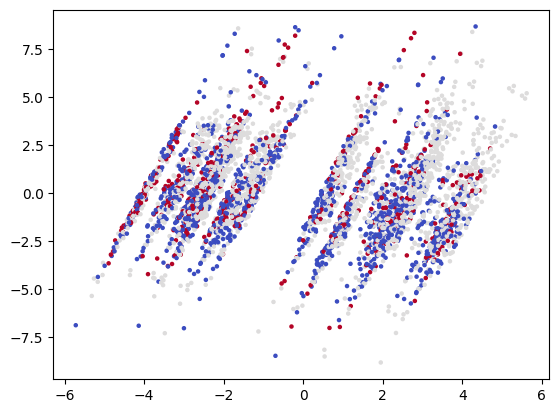

In [59]:
#taking pca to see if I can peck out irrelevant noisy features to remove
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, s=5, cmap="coolwarm")

In [60]:
# Build and train the 3-node SOM
som = OneDSOM(
    n_nodes=3,
    n_features=X_pca.shape[1],
    learning_rate=0.4,
    sigma=2.0,
    n_epochs=2000
)

som.fit(X_pca)

# Assign each sample to 1 of the 3 nodes
som_nodes = som.predict(X_pca)

In [61]:
df_eval = pd.DataFrame({
    'som_node': som_nodes,
    'true_class': y.values   # 1, 2, 3
})

print(df_eval.groupby('som_node')['true_class'].value_counts())

som_node  true_class
0         2             1076
          1              671
          3              250
1         2              384
          1              348
          3              137
2         2              573
          1              320
          3              239
Name: count, dtype: int64


In [62]:
node_to_class = (
    df_eval.groupby('som_node')['true_class']
    .agg(lambda x: x.mode()[0])
)

print("Node → Assigned Class Mapping:")
print(node_to_class)

Node → Assigned Class Mapping:
som_node
0    2
1    2
2    2
Name: true_class, dtype: int32


In [63]:
som_predicted_classes = np.array([node_to_class[n] for n in som_nodes])

In [64]:
acc = accuracy_score(y, som_predicted_classes)
print("SOM Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y, som_predicted_classes))

print("\nConfusion Matrix:")
print(confusion_matrix(y, som_predicted_classes))

SOM Accuracy: 0.508504252126063

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      1339
           2       0.51      1.00      0.67      2033
           3       0.00      0.00      0.00       626

    accuracy                           0.51      3998
   macro avg       0.17      0.33      0.22      3998
weighted avg       0.26      0.51      0.34      3998


Confusion Matrix:
[[   0 1339    0]
 [   0 2033    0]
 [   0  626    0]]


c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

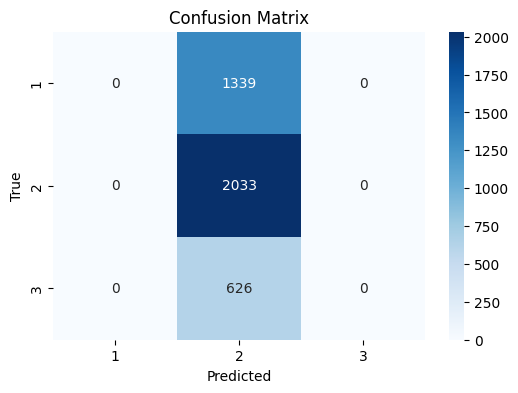

In [66]:
# plot confusion matrix
# labels -> human readable names (matches 1,2,3)
target_labels = [1, 2, 3]
target_names = ['increase', 'decrease', 'no_change']
cm = confusion_matrix(y, som_predicted_classes, labels=target_labels)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()